# Actividad: paradoja de Simpson en fútbol

Este ejemplo simula una relación entre **goles por 90 minutos** y **valor de mercado** para dos posiciones: delanteros y mediocampistas. Los datos son ficticios y se construyen deliberadamente para exhibir una inversión de la asociación al agrupar las posiciones.

## Variables y pregunta

- Variable predictora $X$: goles por 90 minutos.
- Variable respuesta $Y$: valor de mercado del jugador, en millones de euros.
- Variable categórica $G$: posición; $G=1$ si el jugador es delantero y $G=0$ si es mediocampista.

Pregunta: **¿los jugadores que anotan más goles por 90 minutos tienen mayor valor de mercado?**

El susto aparece si se responde la pregunta sin mirar la posición: en el total parecerá que más goles se asocian con menor valor. Sin embargo, dentro de delanteros y dentro de mediocampistas, la asociación será positiva.

## Mecanismo de generación de datos

Para cada jugador $i$, se genera $G_i$ con igual probabilidad para ambas posiciones. Luego:

$$
X_i \mid G_i=1 \sim \mathcal{N}(0.52, 0.12^2),
\qquad
X_i \mid G_i=0 \sim \mathcal{N}(0.38, 0.12^2).
$$

Finalmente, con $\varepsilon_i \sim \mathcal{N}(0,3.5^2)$ independiente de $X_i$ y $G_i$:

$$
Y_i = 13 + 8X_i + \varepsilon_i \quad \text{si } G_i=1,
$$

$$
Y_i = 20 + 8X_i + \varepsilon_i \quad \text{si } G_i=0.
$$

La pendiente es $8>0$ en ambas posiciones. Pero los delanteros tienen, en promedio, más goles por 90 y un valor base menor; los mediocampistas tienen menos goles por 90 y un valor base mayor. La superposición entre ambos grupos es parcial, pero esta composición todavía induce la inversión en el análisis agregado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
players_per_position = 120

forward_goals = rng.normal(loc=0.52, scale=0.12, size=players_per_position)
midfielder_goals = rng.normal(loc=0.38, scale=0.12, size=players_per_position)

forward_value = 13 + 8 * forward_goals + rng.normal(0, 3.5, players_per_position)
midfielder_value = 20 + 8 * midfielder_goals + rng.normal(0, 3.5, players_per_position)

data = pd.DataFrame({
    'G': [1] * players_per_position + [0] * players_per_position,
    'X': np.concatenate([forward_goals, midfielder_goals]),
    'Y': np.concatenate([forward_value, midfielder_value]),
})

data.head()

/Users/matmoran/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/k6/hrg1wzm97gv3qh2spzzxzr308t31w7/T/matplotlib-s7f2bdq4 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


,G,X,Y
0,1,0.424825,25.281166
1,1,0.548869,20.818732
2,1,0.292441,17.625538
3,1,0.687493,14.571548
4,1,0.596595,13.851507


In [2]:
def linear_slope(frame):
    return np.polyfit(frame['X'], frame['Y'], deg=1)[0]

associations = pd.DataFrame({
    'group': ['All players', 'Forward', 'Midfielder'],
    'slope': [
        linear_slope(data),
        linear_slope(data[data['G'] == 1]),
        linear_slope(data[data['G'] == 0]),
    ],
})

associations

,group,slope
0,All players,-2.545020
1,Forward,8.233927
2,Midfielder,9.742098


Una pendiente positiva indica asociación positiva entre goles por 90 y valor de mercado; una pendiente negativa indica la asociación opuesta. El valor esperado es: pendiente negativa en el total y positiva en cada posición.

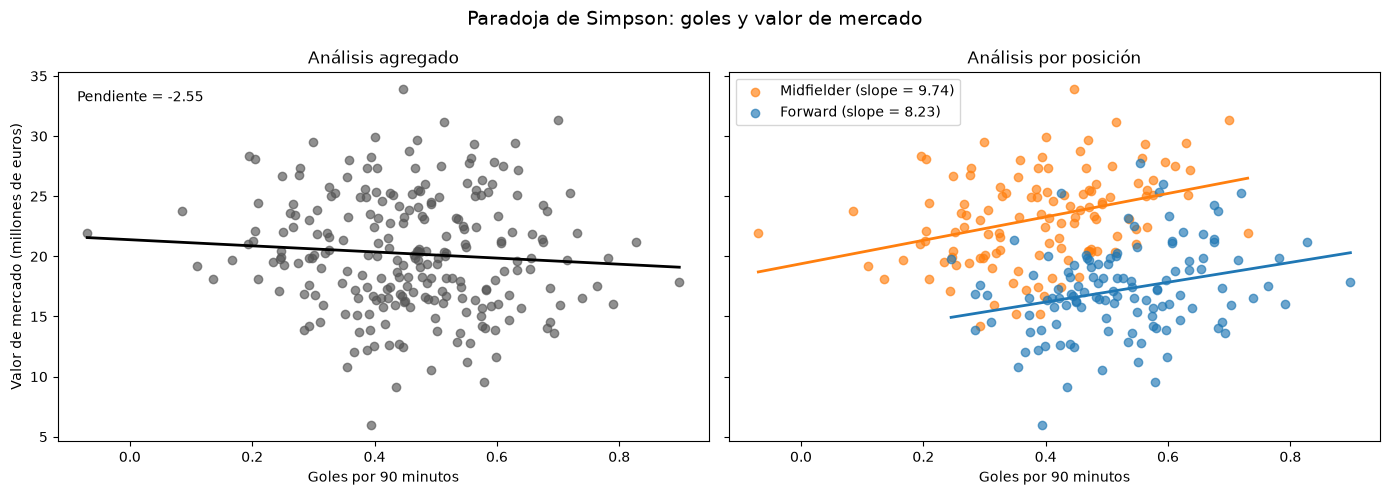

In [3]:
colors = {1: '#1f77b4', 0: '#ff7f0e'}
position_labels = {1: 'Forward', 0: 'Midfielder'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(
    data['X'],
    data['Y'],
    alpha=0.65,
    color='#555555',
)
x_all = np.linspace(data['X'].min(), data['X'].max(), 100)
all_slope, all_intercept = np.polyfit(
    data['X'], data['Y'], deg=1
)
axes[0].plot(x_all, all_slope * x_all + all_intercept, color='black', linewidth=2)
axes[0].set_title('Análisis agregado')
axes[0].set_xlabel('Goles por 90 minutos')
axes[0].set_ylabel('Valor de mercado (millones de euros)')
axes[0].text(0.03, 0.95, f'Pendiente = {all_slope:.2f}', transform=axes[0].transAxes, va='top')

for group, frame in data.groupby('G'):
    slope, intercept = np.polyfit(frame['X'], frame['Y'], deg=1)
    x_values = np.linspace(frame['X'].min(), frame['X'].max(), 100)
    axes[1].scatter(
        frame['X'],
        frame['Y'],
        alpha=0.65,
        color=colors[group],
        label=f'{position_labels[group]} (slope = {slope:.2f})',
    )
    axes[1].plot(x_values, slope * x_values + intercept, color=colors[group], linewidth=2)

axes[1].set_title('Análisis por posición')
axes[1].set_xlabel('Goles por 90 minutos')
axes[1].legend()

fig.suptitle('Paradoja de Simpson: goles y valor de mercado', fontsize=14)
fig.tight_layout()
plt.show()

## Conclusión

La asociación agregada responde una comparación entre poblaciones de jugadores distintas: los delanteros se concentran en valores mayores de $X$ y los mediocampistas en valores mayores de $Y$. Por eso, no describe la asociación dentro de una misma posición.

La pregunta debería reformularse como: **manteniendo fija la posición, ¿cómo se asocian los goles por 90 con el valor de mercado?** En los datos simulados, la respuesta es positiva para ambas posiciones. El ejemplo describe asociaciones y no permite, por sí solo, concluir que anotar más goles cause un mayor valor de mercado.